<a href="https://colab.research.google.com/github/Vaishakh252/Delhivery_case_study/blob/main/Delhivery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('delhivery_data.csv')

In [ ]:
df.dtypes

,0
data,object
trip_creation_time,object
route_schedule_uuid,object
route_type,object
trip_uuid,object
source_center,object
source_name,object
destination_center,object
destination_name,object
od_start_time,object


In [ ]:
df.nunique()

,0
data,2
trip_creation_time,14817
route_schedule_uuid,1504
route_type,2
trip_uuid,14817
source_center,1508
source_name,1498
destination_center,1481
destination_name,1468
od_start_time,26369


In [ ]:
df.shape

(144867, 24)

In [ ]:
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


In [ ]:
df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'])
df['od_start_time'] = pd.to_datetime(df['od_start_time'])
df['od_end_time'] = pd.to_datetime(df['od_end_time'])

In [ ]:
# Extract features from trip_creation_time
df['year'] = df['trip_creation_time'].dt.year
df['month'] = df['trip_creation_time'].dt.month
df['day'] = df['trip_creation_time'].dt.day
df['hour'] = df['trip_creation_time'].dt.hour

# Splitting source_name and destination_name into city and state (assuming format 'city-place-code (state)')
df[['source_city', 'source_state']] = df['source_name'].str.extract(r'([A-Za-z]+)-.+\((\w+)\)')
df[['destination_city', 'destination_state']] = df['destination_name'].str.extract(r'([A-Za-z]+)-.+\((\w+)\)')


In [ ]:
# Group by trip_uuid and aggregate necessary fields
agg_dict = {
    'actual_time': 'sum',
    'osrm_time': 'sum',
    'osrm_distance': 'sum',
    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',
    'segment_osrm_distance': 'sum',
    'start_scan_to_end_scan': 'sum',
    'trip_creation_time': 'first',  # take the first timestamp
    'od_start_time': 'first',
    'od_end_time': 'last'
}

# Grouping by trip_uuid
df_agg = df.groupby('trip_uuid').agg(agg_dict).reset_index()

# Calculate the total time between od_start_time and od_end_time
df_agg['total_trip_time'] = (df_agg['od_end_time'] - df_agg['od_start_time']).dt.total_seconds() / 3600  # in hours


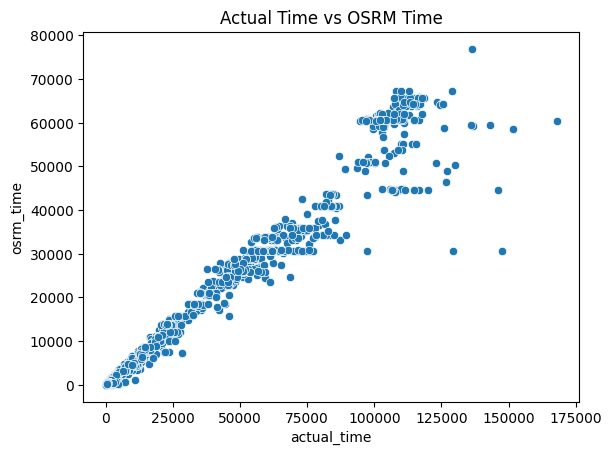

T-test Result: TtestResult(statistic=14.073444960610715, pvalue=7.714905383019579e-45, df=29632.0)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot for actual_time vs osrm_time
sns.scatterplot(x='actual_time', y='osrm_time', data=df_agg)
plt.title('Actual Time vs OSRM Time')
plt.show()

# Hypothesis test (T-test) between actual_time and osrm_time
from scipy.stats import ttest_ind
ttest_result = ttest_ind(df_agg['actual_time'], df_agg['osrm_time'])
print('T-test Result:', ttest_result)


In [ ]:
# Identify outliers using IQR method
Q1 = df_agg['actual_time'].quantile(0.25)
Q3 = df_agg['actual_time'].quantile(0.75)
IQR = Q3 - Q1

# Filter out rows that are outliers
df_no_outliers  = df_agg[(df_agg['actual_time'] >= Q1 - 1.5 * IQR) & (df_agg['actual_time'] <= Q3 + 1.5 * IQR)]


In [ ]:
#check the source center corresponding to the missing source name
#df['source_center'][df['source_name'].isnull()].unique()

In [ ]:
#impute missing values
#df['source_name'].fillna('Unknown',inplace=True)
#df['destination_name'].fillna('Unknown',inplace=True)